1. CHARGEMENT ET EXPLORATION INITIALE DES DONNÉES
Clique sur le bouton ci-dessous pour importer ton fichier Apple_stock.csv :


Saving Apple Stock Prices (1981 to 2023).csv to Apple Stock Prices (1981 to 2023).csv

--- Informations sur le Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10608 non-null  datetime64[ns]
 1   Open       10608 non-null  float64       
 2   High       10608 non-null  float64       
 3   Low        10608 non-null  float64       
 4   Close      10608 non-null  float64       
 5   Adj Close  10608 non-null  float64       
 6   Volume     10608 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 580.3 KB
None

--- Compte des valeurs manquantes par colonne ---
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

--- Aperçu des 5 premières lignes ---
        Date      Open      High       Low     Close  Adj Clos

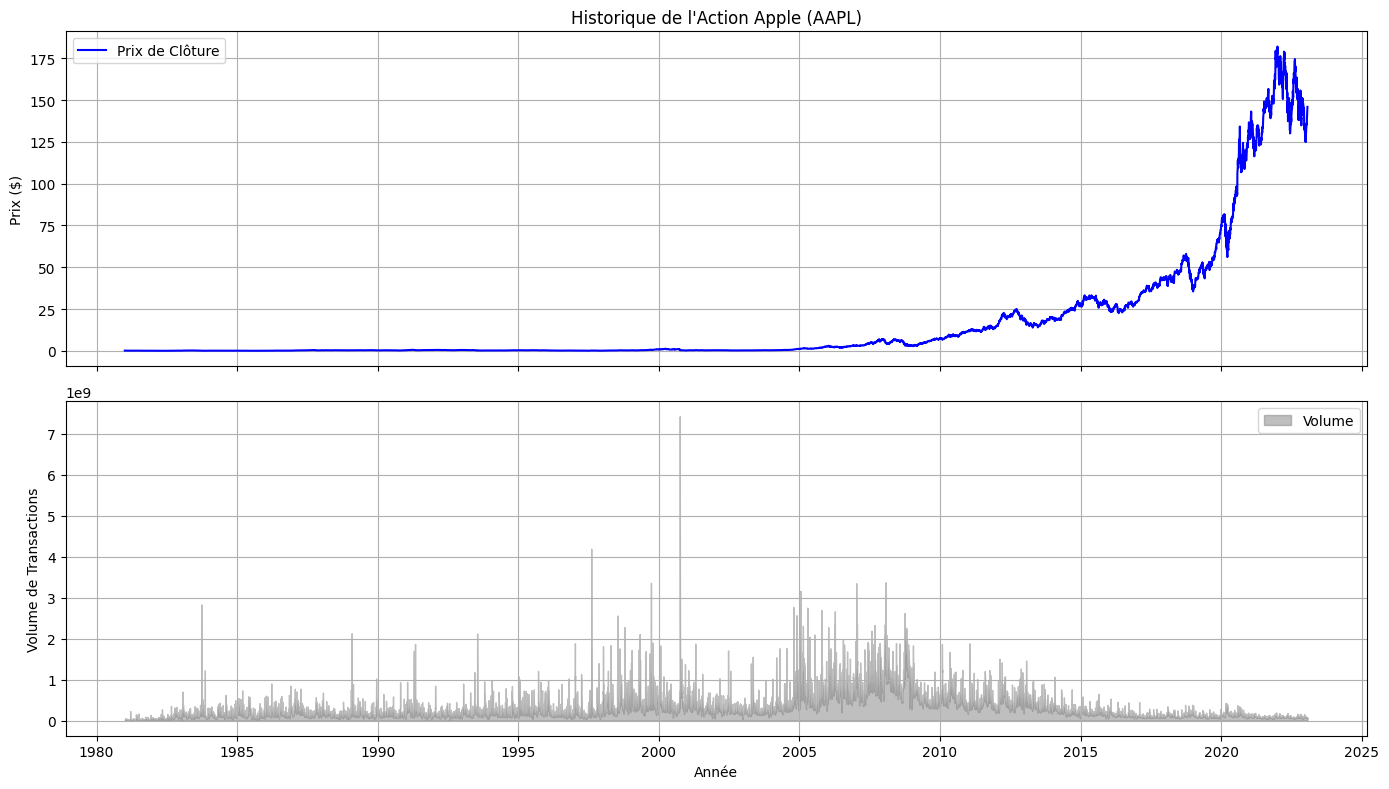

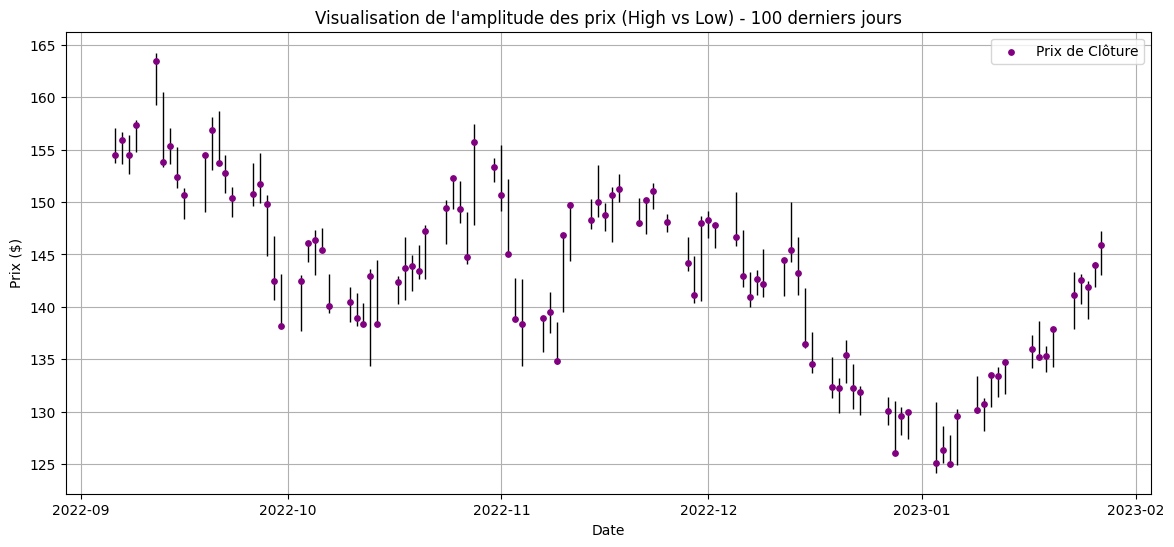


3. ANALYSE STATISTIQUE DESCRIPTIVE
               Open          High           Low         Close        Volume
count  10608.000000  10608.000000  10608.000000  10608.000000  1.060800e+04
mean      16.689173     16.879955     16.500822     16.697362  3.275098e+08
std       35.450519     35.882848     35.031289     35.473912  3.378203e+08
min        0.049665      0.049665      0.049107      0.049107  0.000000e+00
25%        0.287946      0.296875      0.282355      0.288923  1.213044e+08
50%        0.488839      0.495536      0.480446      0.487701  2.145976e+08
75%       16.320893     16.418483     16.151249     16.269554  4.066804e+08
max      182.630005    182.940002    179.119995    182.009995  7.421641e+09

4. TESTS D'HYPOTHÈSES
Nombre d'observations en 2020 : 253
Nombre d'observations en 2022 : 251

--- Test t pour les cours de clôture moyens (2020 vs 2022) ---
Statistique t : -37.1855
P-valeur : 7.8201e-134

--- Test de Normalité sur les Rendements Quotidiens ---
Statistique de t

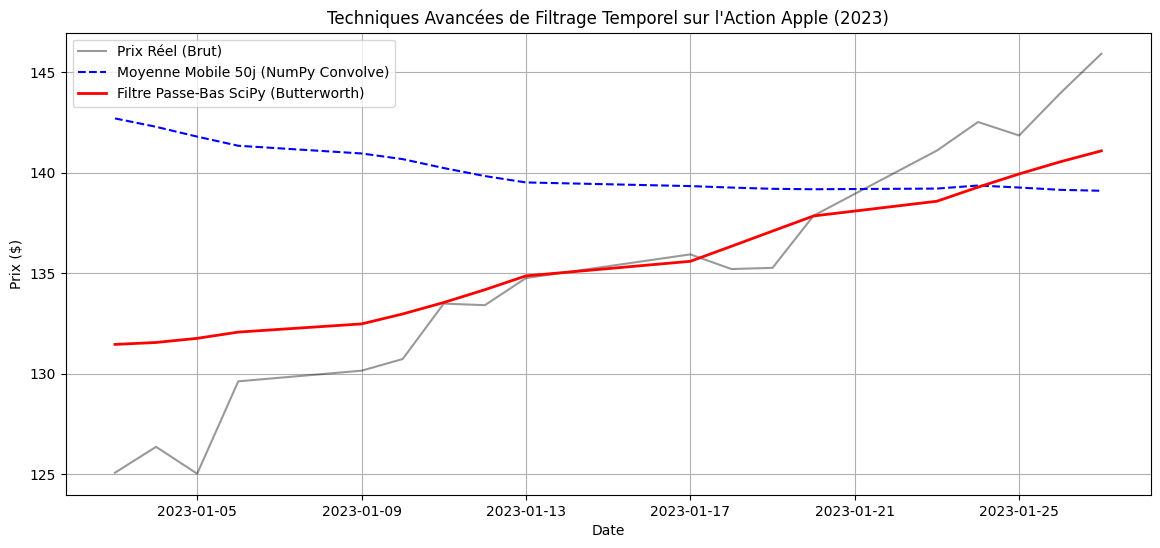


Matrice de corrélation de Pearson entre la Moyenne Mobile (50j) et le Volume :
[[ 1.         -0.21558721]
 [-0.21558721  1.        ]]
Coefficient de corrélation linéaire : -0.2156


In [1]:
import io
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
from scipy import signal, stats

# ==============================================================================
# 1. DATA LOADING AND EXPLORATION
# ==============================================================================
print("=" * 60)
print("1. CHARGEMENT ET EXPLORATION INITIALE DES DONNÉES")
print("=" * 60)
print(
    "Clique sur le bouton ci-dessous pour importer ton fichier Apple_stock.csv :"
)

# Chargement du fichier
uploaded = files.upload()
nom_fichier = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))

# Gestion dynamique du nom de la colonne Date
colonne_date = (
    "Apple Stock Prices (1981 to 2023)"
    if "Apple Stock Prices (1981 to 2023)" in df.columns
    else "Date"
)
df = df.rename(columns={colonne_date: "Date"})

# Conversion des dates (format européen géré) et tri chronologique
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)

# Vérification des types et des valeurs nulles
print("\n--- Informations sur le Dataset ---")
print(df.info())

print("\n--- Compte des valeurs manquantes par colonne ---")
print(df.isnull().sum())

print("\n--- Aperçu des 5 premières lignes ---")
print(df.head())


# ==============================================================================
# 2. DATA VISUALIZATION
# ==============================================================================
print("\n" + "=" * 60)
print("2. VISUALISATION DES DONNÉES")
print("=" * 60)

# Graphique 1 : Prix de Clôture et Volume au fil du temps
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df["Date"], df["Close"], color="blue", label="Prix de Clôture")
ax1.set_title("Historique de l'Action Apple (AAPL)")
ax1.set_ylabel("Prix ($)")
ax1.grid(True)
ax1.legend()

ax2.fill_between(df["Date"], df["Volume"], color="gray", alpha=0.5, label="Volume")
ax2.set_ylabel("Volume de Transactions")
ax2.set_xlabel("Année")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Graphique 2 : Représentation simplifiée en Chandeliers (High / Low / Close)
# Pour une meilleure lisibilité, on échantillonne sur les 100 derniers jours
df_recent = df.tail(100).copy()

plt.figure(figsize=(14, 6))
# Ligne verticale pour l'amplitude de la journée (High - Low)
plt.vlines(
    df_recent["Date"],
    df_recent["Low"],
    df_recent["High"],
    color="black",
    linewidth=1,
)
# Points de clôture
plt.scatter(
    df_recent["Date"],
    df_recent["Close"],
    color="purple",
    s=15,
    label="Prix de Clôture",
    zorder=3,
)
plt.title("Visualisation de l'amplitude des prix (High vs Low) - 100 derniers jours")
plt.xlabel("Date")
plt.ylabel("Prix ($)")
plt.grid(True)
plt.legend()
plt.show()


# ==============================================================================
# 3. STATISTICAL ANALYSIS
# ==============================================================================
print("\n" + "=" * 60)
print("3. ANALYSE STATISTIQUE DESCRIPTIVE")
print("=" * 60)

colonnes_cles = ["Open", "High", "Low", "Close", "Volume"]
stats_descriptives = df[colonnes_cles].describe()
print(stats_descriptives)

# Analyse à l'aide d'une moyenne mobile classique Pandas (Fenêtre de 50 jours)
df["MA_50_Pandas"] = df["Close"].rolling(window=50).mean()


# ==============================================================================
# 4. HYPOTHESIS TESTING
# ==============================================================================
print("\n" + "=" * 60)
print("4. TESTS D'HYPOTHÈSES")
print("=" * 60)

# Extraction des années pour isoler deux sous-périodes à comparer (ex: 2020 vs 2022)
df["Annee"] = df["Date"].dt.year

prix_2020 = df[df["Annee"] == 2020]["Close"].to_numpy()
prix_2022 = df[df["Annee"] == 2022]["Close"].to_numpy()

print(f"Nombre d'observations en 2020 : {len(prix_2020)}")
print(f"Nombre d'observations en 2022 : {len(prix_2022)}")

# 4.1 Test t de Student indépendant (Comparaison de deux années distinctes)
t_stat, p_val_t = stats.ttest_ind(prix_2020, prix_2022, equal_var=False)
print(f"\n--- Test t pour les cours de clôture moyens (2020 vs 2022) ---")
print(f"Statistique t : {t_stat:.4f}")
print(f"P-valeur : {p_val_t:.4e}")

# 4.2 Distribution des rendements quotidiens et Test de Normalité (D'Agostino-Pearson)
df["Daily_Return"] = df["Close"].pct_change()
rendements_propres = df["Daily_Return"].dropna().to_numpy()

stat_norm, p_val_norm = stats.normaltest(rendements_propres)
print(f"\n--- Test de Normalité sur les Rendements Quotidiens ---")
print(f"Statistique de test : {stat_norm:.4f}")
print(f"P-valeur : {p_val_norm:.4e}")

if p_val_norm < 0.05:
    print(
        "Résultat : On rejette H0. Les rendements quotidiens d'Apple NE suivent PAS une loi normale."
    )
else:
    print(
        "Résultat : Échec du rejet de H0. Les rendements suivent une loi normale."
    )


# ==============================================================================
# 5. ADVANCED STATISTICAL TECHNIQUES (BONUS)
# ==============================================================================
print("\n" + "=" * 60)
print("5. TECHNIQUES STATISTIQUES AVANCÉES (BONUS)")
print("=" * 60)

# 5.1 Utilisation de np.convolve pour calculer une moyenne mobile (Fenêtre de 50)
fenetre = 50
weights = np.ones(fenetre) / fenetre
# Mode 'valid' évite les effets de bord artificiels, la taille sera réduite de (fenetre - 1)
ma_convolve = np.convolve(df["Close"].to_numpy(), weights, mode="valid")

# Alignement pour la comparaison avec Pandas (en ajoutant des NaN au début)
ma_convolve_alignee = np.concatenate(([np.nan] * (fenetre - 1), ma_convolve))
df["MA_50_NumPy"] = ma_convolve_alignee

# 5.2 Traitement du signal avec SciPy : Application d'un filtre passe-bas Butterworth
# Utile pour éliminer le bruit quotidien de haute fréquence sans la phase de décalage des MA
b, a = signal.butter(3, 0.05)  # Ordre 3, Fréquence de coupure critique à 0.05
df["Signal_Butterworth"] = signal.filtfilt(b, a, df["Close"].to_numpy())

# Visualisation des techniques avancées sur l'année 2023 pour bien voir la différence
df_2023 = df[df["Annee"] == 2023]

plt.figure(figsize=(14, 6))
plt.plot(
    df_2023["Date"],
    df_2023["Close"],
    label="Prix Réel (Brut)",
    alpha=0.4,
    color="black",
)
plt.plot(
    df_2023["Date"],
    df_2023["MA_50_NumPy"],
    label="Moyenne Mobile 50j (NumPy Convolve)",
    color="blue",
    linestyle="--",
)
plt.plot(
    df_2023["Date"],
    df_2023["Signal_Butterworth"],
    label="Filtre Passe-Bas SciPy (Butterworth)",
    color="red",
    linewidth=2,
)
plt.title("Techniques Avancées de Filtrage Temporel sur l'Action Apple (2023)")
plt.xlabel("Date")
plt.ylabel("Prix ($)")
plt.grid(True)
plt.legend()
plt.show()

# 5.3 Analyse des corrélations (np.corrcoef) entre Moyenne Mobile et Volume
df_sans_nan = df[["MA_50_Pandas", "Volume"]].dropna()
matrice_corr = np.corrcoef(df_sans_nan["MA_50_Pandas"], df_sans_nan["Volume"])
print(
    f"\nMatrice de corrélation de Pearson entre la Moyenne Mobile (50j) et le Volume :"
)
print(matrice_corr)
print(
    f"Coefficient de corrélation linéaire : {matrice_corr[0, 1]:.4f}"
)